# 02 · Feature Engineering

**Input:** `data/cleaned/superstore_clean.csv`
**Output:** `data/processed/superstore_features.csv`, `customer_profile.csv`

26 features across three groups — time, value, and customer. Every one exists because a
specific question or visual needs it; none are added speculatively.

In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

BLUE, TEAL, AMBER, PURPLE, RED = "#2f6fed", "#16a888", "#f5b820", "#7b45c9", "#e03131"
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 140, "savefig.bbox": "tight",
    "font.size": 10, "axes.titlesize": 12, "axes.titleweight": "bold",
    "axes.edgecolor": "#d7dbe3", "grid.color": "#eef0f4", "axes.facecolor": "white",
})
IMAGES = ROOT / "images"; IMAGES.mkdir(exist_ok=True)
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")
money = mticker.FuncFormatter(lambda v, _: f"${v/1000:,.0f}K")

In [2]:
df = pd.read_csv(ROOT / "data" / "cleaned" / "superstore_clean.csv",
                 parse_dates=["order_date", "ship_date"], dtype={"postal_code": str})
print(f"{len(df):,} rows x {df.shape[1]} columns")

9,993 rows x 21 columns


## 1. Time features

In [3]:
d = df.order_date
df["order_year"] = d.dt.year
df["order_month"] = d.dt.month
df["order_month_name"] = d.dt.strftime("%b")
df["order_quarter"] = "Q" + d.dt.quarter.astype(str)
df["year_month"] = d.dt.to_period("M").astype(str)
df["order_day_name"] = d.dt.day_name()

# Weekend orders may behave differently from weekday B2B purchasing - worth testing.
df["is_weekend_order"] = d.dt.dayofweek.isin([5, 6])

# Fulfilment speed, and a flag against a 5-day internal SLA.
df["shipping_days"] = (df.ship_date - d).dt.days
df["is_delayed"] = df.shipping_days > 5

df[["order_date", "order_quarter", "order_day_name",
    "is_weekend_order", "shipping_days", "is_delayed"]].head()

,order_date,order_quarter,order_day_name,is_weekend_order,shipping_days,is_delayed
0,2017-11-08,Q4,Wednesday,False,3,False
1,2017-11-08,Q4,Wednesday,False,3,False
2,2017-06-12,Q2,Monday,False,4,False
3,2016-10-11,Q4,Tuesday,False,7,True
4,2016-10-11,Q4,Tuesday,False,7,True


## 2. Value features

In [4]:
# Guard both denominators - a zero would produce inf rather than raising.
df["profit_margin"] = df.profit / df.sales.where(df.sales != 0) * 100
df["unit_price"] = df.sales / df.quantity.where(df.quantity != 0)
df["is_loss"] = df.profit < 0

# Revenue given away versus list price on each line.
df["discount_value"] = np.where(df.discount < 1,
                                df.sales / (1 - df.discount) - df.sales, 0.0)

df["discount_band"] = pd.cut(df.discount, bins=[-0.01, 0, .15, .30, .50, 1.0],
                             labels=["No discount", "1-15%", "16-30%", "31-50%", "50%+"])

# Size bands cut on quartiles, so they adapt to any extract rather than
# hardcoding thresholds that would go stale.
q = df.sales.quantile([.25, .5, .75]).tolist()
df["sales_category"] = pd.cut(df.sales, bins=[-0.01] + q + [df.sales.max()],
                              labels=["Small", "Medium", "Large", "Very Large"])

df.groupby("discount_band", observed=True).agg(
    lines=("sales", "size"), sales=("sales", "sum"),
    profit=("profit", "sum")).assign(margin=lambda x: x.profit / x.sales * 100)

,lines,sales,profit,margin
discount_band,,,,
No discount,4798,"1,087,908.47","320,987.60",29.51
1-15%,146,"81,927.87","10,448.17",12.75
16-30%,3883,"867,539.65","79,980.09",9.22
31-50%,310,"195,314.76","-48,447.73",-24.80
50%+,856,"64,228.74","-76,559.05",-119.20


The discount bands already show the finding this project is built on: margin is strongly
positive with no discount and deeply negative above 30%. Quantified properly in notebook 03.

## 3. Customer profile and RFM

In [5]:
snapshot = df.order_date.max() + pd.Timedelta(days=1)

prof = df.groupby(["customer_id", "customer_name", "segment"]).agg(
    lifetime_orders=("order_id", "nunique"),
    lifetime_value=("sales", "sum"),
    lifetime_profit=("profit", "sum"),
    avg_discount=("discount", "mean"),
    first_order=("order_date", "min"),
    last_order=("order_date", "max"),
).reset_index()

prof["avg_order_value"] = prof.lifetime_value / prof.lifetime_orders
prof["recency_days"] = (snapshot - prof.last_order).dt.days
prof["is_repeat"] = prof.lifetime_orders > 1

# Relative threshold, not a magic number: the flag stays meaningful as the business grows.
prof["is_high_value"] = prof.lifetime_value >= prof.lifetime_value.quantile(0.80)

print(f"{len(prof):,} customers")
prof.sort_values("lifetime_value", ascending=False).head()

793 customers


,customer_id,customer_name,segment,lifetime_orders,lifetime_value,lifetime_profit,avg_discount,first_order,last_order,avg_order_value,recency_days,is_repeat,is_high_value
700,SM-20320,Sean Miller,Home Office,5,"25,043.05","-1,980.74",0.25,2015-03-18,2018-10-12,"5,008.61",80,True,True
741,TC-20980,Tamara Chand,Corporate,5,"19,052.22","8,981.32",0.12,2015-11-07,2017-11-26,"3,810.44",400,True,True
621,RB-19360,Raymond Buch,Consumer,6,"15,117.34","6,976.10",0.09,2017-04-01,2018-09-25,"2,519.56",97,True,True
730,TA-21385,Tom Ashbrook,Home Office,4,"14,595.62","4,703.79",0.08,2015-09-12,2018-10-22,"3,648.91",70,True,True
6,AB-10105,Adrian Barton,Consumer,10,"14,473.57","5,444.81",0.24,2015-12-20,2018-11-19,"1,447.36",42,True,True


In [6]:
# RFM: 5 is best. Recency is reversed - fewer days since the last order is better.
prof["r_score"] = pd.qcut(prof.recency_days, 5, labels=[5,4,3,2,1]).astype(int)
prof["f_score"] = pd.qcut(prof.lifetime_orders.rank(method="first"), 5,
                          labels=[1,2,3,4,5]).astype(int)
prof["m_score"] = pd.qcut(prof.lifetime_value, 5, labels=[1,2,3,4,5]).astype(int)
prof["rfm_score"] = prof.r_score + prof.f_score + prof.m_score

prof["rfm_segment"] = np.select(
    [prof.rfm_score >= 13, prof.rfm_score >= 10, prof.rfm_score >= 7],
    ["Champion", "Loyal", "Potential"], default="At Risk")

rfm = prof.groupby("rfm_segment").agg(
    customers=("customer_id", "size"), revenue=("lifetime_value", "sum"),
    avg_orders=("lifetime_orders", "mean"), avg_recency=("recency_days", "mean"))
rfm["pct_revenue"] = rfm.revenue / rfm.revenue.sum() * 100
rfm.sort_values("revenue", ascending=False)

,customers,revenue,avg_orders,avg_recency,pct_revenue
rfm_segment,,,,,
Loyal,254,"982,539.38",7.44,75.11,42.78
Champion,124,"647,434.98",9.41,28.06,28.19
Potential,219,"473,123.09",5.58,137.68,20.60
At Risk,196,"193,822.04",3.72,328.96,8.44


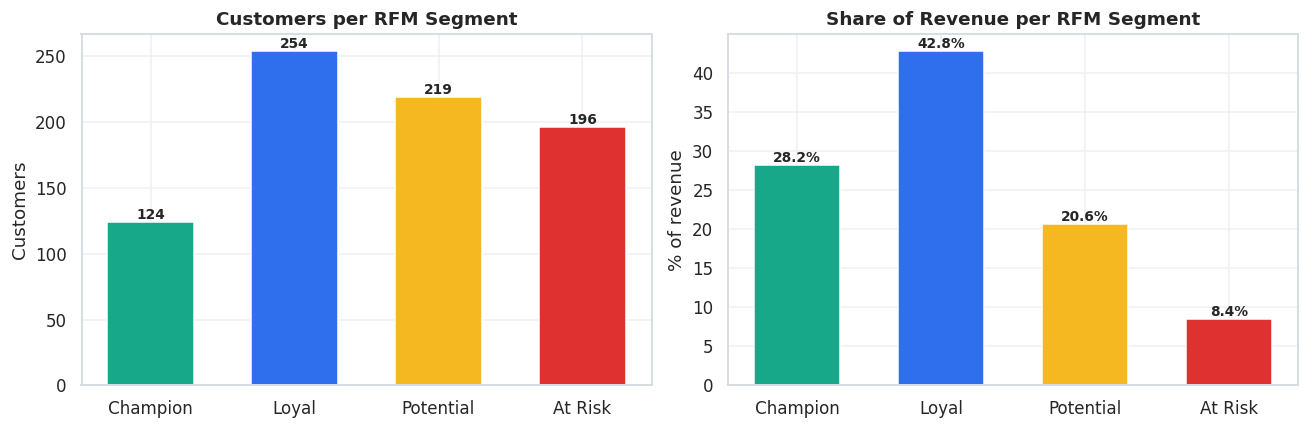

In [7]:
order = ["Champion", "Loyal", "Potential", "At Risk"]
r = rfm.reindex(order)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].bar(order, r.customers, color=[TEAL, BLUE, AMBER, RED], width=.6)
ax[0].set_title("Customers per RFM Segment"); ax[0].set_ylabel("Customers")
ax[1].bar(order, r.pct_revenue, color=[TEAL, BLUE, AMBER, RED], width=.6)
ax[1].set_title("Share of Revenue per RFM Segment"); ax[1].set_ylabel("% of revenue")
for a, vals in [(ax[0], r.customers), (ax[1], r.pct_revenue)]:
    for x, v in zip(order, vals):
        a.text(x, v, f"{v:,.0f}" if v > 100 else f"{v:.1f}%",
               ha="center", va="bottom", fontsize=9, weight="bold")
plt.tight_layout(); plt.savefig(IMAGES / "rfm_segments.png"); plt.show()

**Finding.** *At Risk* is 24.7% of the customer base but only 8.4% of revenue, with an
average of 329 days since their last order. *Champions* are 15.6% of customers and 28.2%
of revenue. The win-back list is large but individually low-value — worth an automated
email sequence rather than sales time.

## 4. Attach and save

In [8]:
df = df.merge(prof[["customer_id", "lifetime_orders", "lifetime_value",
                    "is_high_value", "is_repeat", "rfm_segment"]],
              on="customer_id", how="left")

# This notebook shows the reasoning; src/feature_engineering.py is the single source
# of truth and writes the canonical files. Deliberately not overwriting them here -
# a notebook that half-rebuilds a pipeline artefact is how silent drift starts.
canonical = pd.read_csv(ROOT / "data" / "processed" / "superstore_features.csv",
                        nrows=1)

print(f"This notebook  : {len(df):,} rows x {df.shape[1]} columns")
print(f"Pipeline output: {canonical.shape[1]} columns "
      f"(adds order_week, year_quarter, margin_band and other variants)")
print(f"Customers      : {len(prof):,} rows x {prof.shape[1]} columns")

This notebook  : 9,993 rows x 41 columns
Pipeline output: 47 columns (adds order_week, year_quarter, margin_band and other variants)
Customers      : 793 rows x 18 columns


→ Continue to `03_eda.ipynb`